# Phishing Site URL Detection

This project aims to test if a website is a phishing website or not based on it's url, we have a dataset with 549346 entries that tells us if it is either a good or bad url, using this we can make a ml model to predict if a website is likely a phishing website or legit


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("taruntiwarihp/phishing-site-urls")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'phishing-site-urls' dataset.
Path to dataset files: /kaggle/input/phishing-site-urls


# Import the Dependencies

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create the df and clean up the dataset

In [11]:
print(os.listdir(path))

['phishing_site_urls.csv']


In [12]:
df = pd.read_csv(path + '/phishing_site_urls.csv')

In [13]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [16]:
df.shape

(549346, 2)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [18]:
df.isnull().sum()

,0
URL,0
Label,0


great no missing data

In [19]:
df.Label.value_counts()

,count
Label,
good,392924
bad,156422


In [20]:
from nltk.tokenize import RegexpTokenizer

In [21]:
tokenizer = RegexpTokenizer(r'\w+')

In [22]:
df.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [23]:
tokenizer.tokenize(df.URL[0])

['nobell',
 'it',
 '70ffb52d079109dca5664cce6f317373782',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 '70ffb52d079109dca5664cce6f317373',
 'index',
 'php',
 'cmd',
 '_profile',
 'ach',
 'outdated_page_tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 '0',
 '5',
 '1',
 'login_access',
 '1322408526']

In [24]:
df['text_tokenized'] = df.URL.map(lambda t: tokenizer.tokenize(t))

In [25]:
df.head()

,URL,Label,text_tokenized
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, 70ffb52d079109dca5664cce6f3173737..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi..."


Now that we have tokenized the data, let's also make lowercase, remove stop words, and stemming

In [26]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [27]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def process_tokens(tokens):
    # Lowercasing and removing stopwords
    filtered_tokens = [word.lower() for word in tokens if word.lower() not in stop_words]
    # Stemming
    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
    return stemmed_tokens

In [28]:
df['processed_tokens'] = df['text_tokenized'].apply(process_tokens)

In [29]:
df.head()

,URL,Label,text_tokenized,processed_tokens
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, 70ffb52d079109dca5664cce6f3173737...","[nobel, 70ffb52d079109dca5664cce6f317373782, l..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, herf..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [30]:
df['text'] = df['processed_tokens'].apply(lambda x: ' '.join(x))

In [31]:
df.head()

,URL,Label,text_tokenized,processed_tokens,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, 70ffb52d079109dca5664cce6f3173737...","[nobel, 70ffb52d079109dca5664cce6f317373782, l...",nobel 70ffb52d079109dca5664cce6f317373782 logi...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, herf...",serviciosbi com paypal cgi bin get herf secur ...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [32]:
good_sites = df[df.Label == 'good']
bad_sites = df[df.Label == 'bad']

In [33]:
good_sites.head()

,URL,Label,text_tokenized,processed_tokens,text
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wVö, ÆåyDaHðû, ÏyEùu,...","[www, eira, nvinip, nch, wvö, æåydahðû, ïyeùu,...",www eira nvinip nch wvö æåydahðû ïyeùu ë ó 6 r...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk óij r...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Yìê, koãÕ, Î, DéÎ, l½ñ, ââqtò, à, Í]","[yìê, koãõ, î, déî, l½ñ, ââqtò, à, í]",yìê koãõ î déî l½ñ ââqtò à í
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta89fm, com, images, AS, Vies, 1i75cf7b16vc...","[ruta89fm, com, imag, vie, 1i75cf7b16vc, f, d1...",ruta89fm com imag vie 1i75cf7b16vc f d16b96 g ...


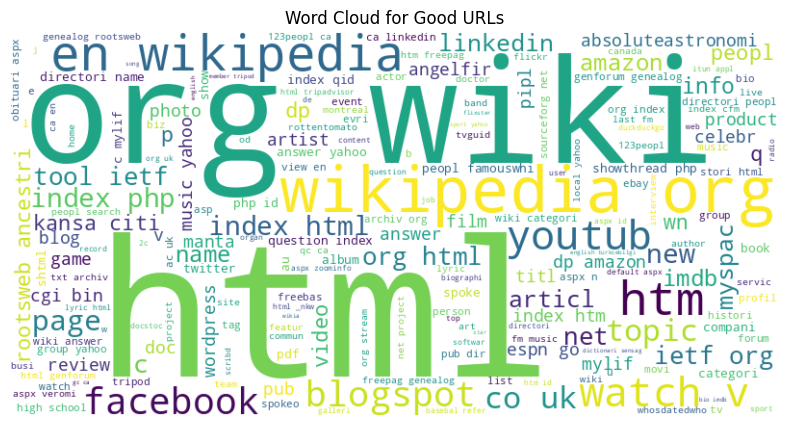

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all 'text' from good sites into a single string
good_text = ' '.join(good_sites['text'])

# Generate a word cloud for good sites
good_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(good_text)

# Plot the word cloud for good sites
plt.figure(figsize=(10, 5))
plt.imshow(good_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Good URLs')
plt.show()

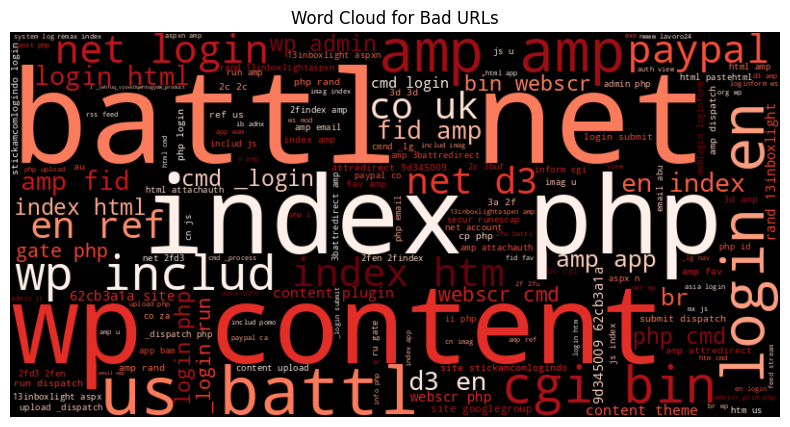

In [35]:
# Combine all 'text' from bad sites into a single string
bad_text = ' '.join(bad_sites['text'])

# Generate a word cloud for bad sites
bad_wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(bad_text)

# Plot the word cloud for bad sites
plt.figure(figsize=(10, 5))
plt.imshow(bad_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Bad URLs')
plt.show()

Well this gives a little big of analysis on our dataset and what exactly in the url's attributes to a good one vs a bad one? seems like org and wiki and html are showing up a lot in our good ones, I think we can get some pretty accurate results just looking at these wordclouds

# Train the model

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

In [38]:
cv = CountVectorizer()
features = cv.fit_transform(df.text)

In [39]:
features[:5].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_train, x_test, y_train, y_test = train_test_split(features, df.Label, test_size = 0.2)

In [42]:
from sklearn.linear_model import LogisticRegression
l_model = LogisticRegression()
l_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [43]:
l_model.score(x_test, y_test)

0.9626467643578774

In [44]:
l_model.score(x_train, y_train)

0.9781125704247786

honestly those results are pretty damn good I was going to maybe do some ensemble model and testing for other models but that performed well and the model does not appear to be overfitted either

In [45]:
from sklearn.metrics import classification_report

In [46]:
print('\nClassification Report')
print(classification_report(y_test, l_model.predict(x_test)))


Classification Report
              precision    recall  f1-score   support

         bad       0.97      0.90      0.93     31152
        good       0.96      0.99      0.97     78718

    accuracy                           0.96    109870
   macro avg       0.96      0.94      0.95    109870
weighted avg       0.96      0.96      0.96    109870



In [47]:
from sklearn.metrics import confusion_matrix

In [50]:
con_mat = pd.DataFrame(confusion_matrix(l_model.predict(x_test), y_test),
            columns = ['Predicted:Bad', 'Predicted:Good'],
            index = ['Actual:Bad', 'Actual:Good'])

In [52]:
con_mat

,Predicted:Bad,Predicted:Good
Actual:Bad,27917,869
Actual:Good,3235,77849


Confusion Matrix


<Axes: >

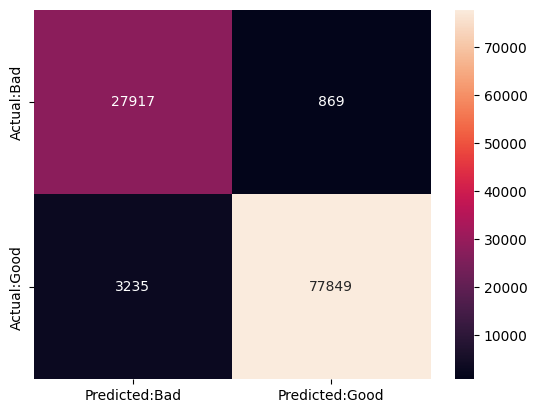

In [53]:
import seaborn as sns

print("Confusion Matrix")
sns.heatmap(con_mat, annot=True, fmt='d')

# Save the Model

In [54]:
import pickle
pickle.dump(l_model, open('phishing.pkl', 'wb'))
pickle.dump(cv, open('vectorizer.pkl', 'wb'))